In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import joblib
import os
import warnings
from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score
from sklearn.preprocessing    import StandardScaler
from scipy.spatial.distance   import cdist
 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

##  Load Datasets

In [14]:
eq  = pd.read_csv('../data/earthquake_data.csv')
apt = pd.read_csv('../data/airports.csv')          # adjust path as needed
 
print(f"Earthquakes : {eq.shape}")
print(f"Airports    : {apt.shape}")
eq.head(3)

Earthquakes : (782, 19)
Airports    : (85549, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.0,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.0,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.0,-20.0508,-178.346,NaN,Oceania,Fiji


## Clean Earthquake Data

In [15]:
# We only need coordinates for clustering
coords_eq = eq[['latitude', 'longitude']].dropna().reset_index(drop=True)
print(f"Clean earthquake coords: {coords_eq.shape}")

Clean earthquake coords: (782, 2)


## Clean Airport Data

In [16]:
# Keep only airports with scheduled service (real commercial airports)
# and valid coordinates.  Filter by type to avoid helipads and balloonports.

KEEP_TYPES = ['large_airport', 'medium_airport']
 
apt_clean = (
    apt[apt['type'].isin(KEEP_TYPES)]
      .dropna(subset=['latitude_deg', 'longitude_deg'])
      .rename(columns={'latitude_deg': 'lat', 'longitude_deg': 'lon'})
      [['name', 'iata_code', 'type', 'lat', 'lon', 'iso_country', 'municipality']]
      .reset_index(drop=True)
)
 
print(f"Usable airports: {apt_clean.shape[0]}")
apt_clean['type'].value_counts()
 

Usable airports: 5277


type
medium_airport    4099
large_airport     1178
Name: count, dtype: int64

## Find Optimal k with Elbow + Silhouette 

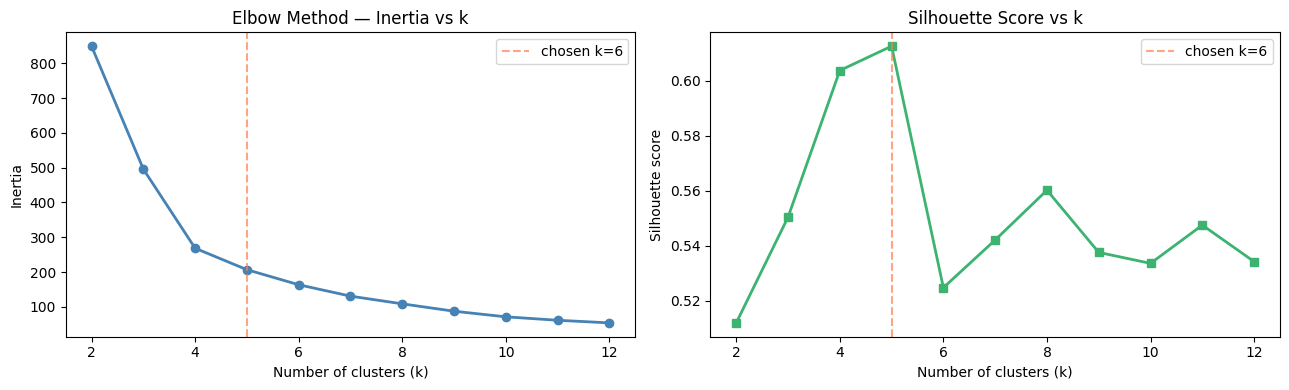

 k    inertia  silhouette
 2 848.952449    0.511877
 3 495.913344    0.550373
 4 268.689215    0.603815
 5 207.030923    0.612680
 6 163.838618    0.524711
 7 131.059800    0.542073
 8 108.965617    0.560213
 9  87.772560    0.537555
10  71.661413    0.533556
11  61.806190    0.547495
12  54.268121    0.534196


In [17]:
# We scale lat/lon so degrees of latitude and longitude have equal weight.
# (One degree of longitude at the equator ≈ one degree of latitude ≈ 111 km,
#  but near the poles longitude degrees compress — scaling handles this.)
 
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(coords_eq[['latitude', 'longitude']])
 
k_range    = range(2, 13)
inertias   = []
silhouettes = []
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=5, color='coral', linestyle='--', alpha=0.7, label='chosen k=6')
axes[0].legend()
 
axes[1].plot(list(k_range), silhouettes, 's-', color='mediumseagreen', linewidth=2)
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].axvline(x=5, color='coral', linestyle='--', alpha=0.7, label='chosen k=6')
axes[1].legend()
 
plt.tight_layout()
plt.show()
 
# Print the scores
results_df = pd.DataFrame({'k': list(k_range),
                            'inertia': inertias,
                            'silhouette': silhouettes})
print(results_df.to_string(index=False))

## Fit Final KMeans (k=6)

In [18]:
# Adjust k here based on what the elbow/silhouette plots told you above.
CHOSEN_K = 5
 
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=15)
coords_eq['cluster'] = km_final.fit_predict(X_scaled)
 
# Inverse-transform centroids back to real lat/lon
centroids_scaled = km_final.cluster_centers_
centroids_latlon = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_latlon, columns=['centroid_lat', 'centroid_lon'])
centroids_df['cluster_id'] = range(CHOSEN_K)
 
print("Raw cluster centroids (may be in water):")
print(centroids_df.round(4))

Raw cluster centroids (may be in water):
   centroid_lat  centroid_lon  cluster_id
0       37.2626      114.0146           0
1       -7.9266      140.3354           1
2      -29.4159     -100.1896           2
3       51.3679     -143.2088           3
4       11.1873      -86.9120           4


## Snap Each Centroid to Nearest Airport

In [19]:
# Haversine distance — properly accounts for Earth's curvature.
 
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine: returns distance in km between (lat1,lon1) and arrays (lat2,lon2)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))
 
 
apt_lats = apt_clean['lat'].values
apt_lons = apt_clean['lon'].values
 
hubs = []
for _, row in centroids_df.iterrows():
    dists = haversine_km(row['centroid_lat'], row['centroid_lon'], apt_lats, apt_lons)
    nearest_idx = np.argmin(dists)
    nearest_apt = apt_clean.iloc[nearest_idx]
    hubs.append({
        'hub_id'        : int(row['cluster_id']),
        'centroid_lat'  : row['centroid_lat'],
        'centroid_lon'  : row['centroid_lon'],
        'hub_lat'       : nearest_apt['lat'],
        'hub_lon'       : nearest_apt['lon'],
        'airport_name'  : nearest_apt['name'],
        'iata_code'     : nearest_apt['iata_code'],
        'country'       : nearest_apt['iso_country'],
        'airport_type'  : nearest_apt['type'],
        'dist_centroid_to_hub_km': round(dists[nearest_idx], 1),
    })
 
hubs_df = pd.DataFrame(hubs)
print("\nFinal supply hubs (snapped to airports):")
print(hubs_df[['hub_id','airport_name','iata_code','country',
               'hub_lat','hub_lon','dist_centroid_to_hub_km']].to_string(index=False))
 


Final supply hubs (snapped to airports):
 hub_id                                       airport_name iata_code country    hub_lat     hub_lon  dist_centroid_to_hub_km
      0                                     Handan Airport       HDG      CN  36.524824  114.424126                     89.8
      1                        Mopah International Airport       MKQ      ID  -8.523898  140.419693                     67.1
      2                     Mataveri International Airport       IPC      CL -27.165411 -109.421027                    937.6
      3                                   Sandspit Airport       YZP      CA  53.254299 -131.813995                    801.6
      4 Augusto C. Sandino (Managua) International Airport       MGA      NI  12.141500  -86.168198                    133.5


## Cluster Summary Statistics

In [20]:
cluster_stats = coords_eq.groupby('cluster').agg(
    earthquake_count=('latitude', 'count'),
    mean_lat=('latitude', 'mean'),
    mean_lon=('longitude', 'mean'),
).reset_index()
 
summary = cluster_stats.merge(
    hubs_df[['hub_id','airport_name','iata_code','country','dist_centroid_to_hub_km']],
    left_on='cluster', right_on='hub_id'
).drop('hub_id', axis=1)
 
print("\nCluster summary:")
print(summary.to_string(index=False))


Cluster summary:
 cluster  earthquake_count   mean_lat    mean_lon                                       airport_name iata_code country  dist_centroid_to_hub_km
       0               168  37.262595  114.014649                                     Handan Airport       HDG      CN                     89.8
       1               350  -7.926588  140.335395                        Mopah International Airport       MKQ      ID                     67.1
       2               133 -29.415943 -100.189622                     Mataveri International Airport       IPC      CL                    937.6
       3                43  51.367898 -143.208770                                   Sandspit Airport       YZP      CA                    801.6
       4                88  11.187328  -86.912027 Augusto C. Sandino (Managua) International Airport       MGA      NI                    133.5


## Matplotlib Overview Map

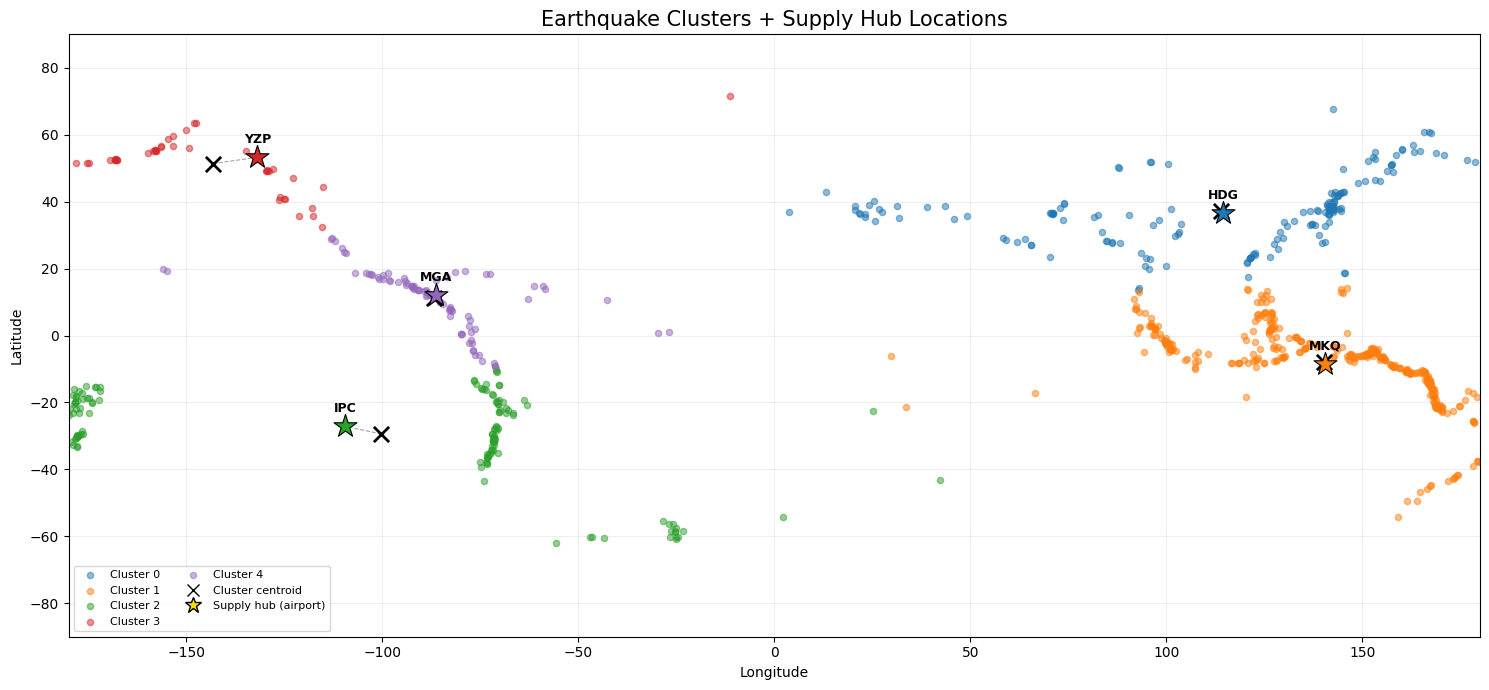

In [21]:
fig, ax = plt.subplots(figsize=(15, 7))
 
palette = plt.cm.tab10.colors
for c_id in range(CHOSEN_K):
    mask = coords_eq['cluster'] == c_id
    ax.scatter(
        coords_eq.loc[mask, 'longitude'],
        coords_eq.loc[mask, 'latitude'],
        s=20, alpha=0.5, color=palette[c_id], label=f'Cluster {c_id}'
    )
    # Raw centroid
    ax.scatter(
        centroids_df.loc[c_id, 'centroid_lon'],
        centroids_df.loc[c_id, 'centroid_lat'],
        marker='x', s=120, color='black', linewidths=2, zorder=5
    )
    # Snapped hub
    ax.scatter(
        hubs_df.loc[c_id, 'hub_lon'],
        hubs_df.loc[c_id, 'hub_lat'],
        marker='*', s=300, color=palette[c_id], edgecolors='black', linewidths=0.8, zorder=6
    )
    # Line from centroid to hub
    ax.plot(
        [centroids_df.loc[c_id, 'centroid_lon'], hubs_df.loc[c_id, 'hub_lon']],
        [centroids_df.loc[c_id, 'centroid_lat'], hubs_df.loc[c_id, 'hub_lat']],
        '--', color='gray', linewidth=0.8, alpha=0.7, zorder=4
    )
    # Label
    ax.annotate(
        hubs_df.loc[c_id, 'iata_code'] if pd.notna(hubs_df.loc[c_id, 'iata_code'])
        else hubs_df.loc[c_id, 'airport_name'][:8],
        xy=(hubs_df.loc[c_id, 'hub_lon'], hubs_df.loc[c_id, 'hub_lat']),
        fontsize=9, fontweight='bold', ha='center', va='bottom',
        xytext=(0, 8), textcoords='offset points'
    )
 
# Legend entries
from matplotlib.lines import Line2D
legend_extra = [
    Line2D([0],[0], marker='x',  color='black', linestyle='None', markersize=8, label='Cluster centroid'),
    Line2D([0],[0], marker='*',  color='gold',  linestyle='None', markersize=12,
           markeredgecolor='black', label='Supply hub (airport)'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_extra,
          loc='lower left', fontsize=8, ncol=2)
 
ax.set_title('Earthquake Clusters + Supply Hub Locations', fontsize=15)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
 

## Interactive Folium Map

In [22]:
hub_colors = ['red','blue','green','purple','orange','darkred',
              'lightred','beige','darkblue','darkgreen']
 
m = folium.Map(location=[0, 100], zoom_start=3, tiles='CartoDB positron')
 
# Earthquake points — per cluster
for c_id in range(CHOSEN_K):
    cluster_pts = coords_eq[coords_eq['cluster'] == c_id]
    for _, pt in cluster_pts.iterrows():
        folium.CircleMarker(
            location=[pt['latitude'], pt['longitude']],
            radius=3, color=hub_colors[c_id % len(hub_colors)],
            fill=True, fill_opacity=0.4, weight=0,
            tooltip=f"Cluster {c_id}"
        ).add_to(m)
 
# Supply hubs — star markers
for _, hub in hubs_df.iterrows():
    cid = int(hub['hub_id'])
    name = hub['airport_name']
    iata = hub['iata_code'] if pd.notna(hub['iata_code']) else 'N/A'
    folium.Marker(
        location=[hub['hub_lat'], hub['hub_lon']],
        icon=folium.Icon(color=hub_colors[cid % len(hub_colors)],
                         icon='plane', prefix='fa'),
        popup=folium.Popup(
            f"<b>Supply Hub {cid}</b><br>"
            f"{name}<br>"
            f"IATA: {iata}<br>"
            f"Country: {hub['country']}<br>"
            f"Cluster size: {summary.loc[summary['cluster']==cid,'earthquake_count'].values[0]}",
            max_width=250
        ),
        tooltip=f"Hub {cid}: {iata}"
    ).add_to(m)
 
    # Dashed line: centroid → hub
    folium.PolyLine(
        locations=[
            [hub['centroid_lat'], hub['centroid_lon']],
            [hub['hub_lat'],      hub['hub_lon']]
        ],
        color='gray', weight=1.5, dash_array='6 4',
        tooltip=f"Shift: {hub['dist_centroid_to_hub_km']} km"
    ).add_to(m)
 
m.save('../maps/supply_hubs_map.html')
print("Saved: supply_hubs_map.html")
m   # renders inline in Jupyter

Saved: supply_hubs_map.html


## Save Artefacts

In [23]:
os.makedirs('../models', exist_ok=True)
 
joblib.dump(km_final,   '../models/kmeans_model.pkl')
joblib.dump(scaler,     '../models/hub_scaler.pkl')
hubs_df.to_csv(         '../models/supply_hubs.csv', index=False)
 
print("Saved: kmeans_model.pkl")
print("Saved: hub_scaler.pkl")
print("Saved: supply_hubs.csv")
print(f"\nSupply hub summary ({CHOSEN_K} hubs):")
print(hubs_df[['hub_id','airport_name','iata_code','hub_lat','hub_lon']].to_string(index=False))

Saved: kmeans_model.pkl
Saved: hub_scaler.pkl
Saved: supply_hubs.csv

Supply hub summary (5 hubs):
 hub_id                                       airport_name iata_code    hub_lat     hub_lon
      0                                     Handan Airport       HDG  36.524824  114.424126
      1                        Mopah International Airport       MKQ  -8.523898  140.419693
      2                     Mataveri International Airport       IPC -27.165411 -109.421027
      3                                   Sandspit Airport       YZP  53.254299 -131.813995
      4 Augusto C. Sandino (Managua) International Airport       MGA  12.141500  -86.168198
